In [1]:
!pip install GEOparse pandas numpy scikit-learn matplotlib torch torchvision imbalanced-learn --quiet

import GEOparse
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import torch
import torch.nn as nn
import torch.optim as optim

In [2]:
# Step 1: Load GEO Dataset (GSE70947)
gse_id = "GSE70947"
gse = GEOparse.get_GEO(geo=gse_id, destdir="./")

# Step 2: Extract Metadata (Phenotype labels: Cancer vs. No Cancer)
metadata = pd.DataFrame({
    "Sample": list(gse.gsms.keys()),
    "Condition": [gse.gsms[sample].metadata['characteristics_ch1'][0] for sample in gse.gsms]
})

# Step 3: Extract Gene Expression Data (Probe_ID vs. Sample)
expression_data = gse.pivot_samples("VALUE")

# Step 4: Merge Expression Data with Metadata
merged_data = expression_data.T.merge(metadata, left_index=True, right_on="Sample")


12-Apr-2025 06:13:37 DEBUG utils - Directory ./ already exists. Skipping.
12-Apr-2025 06:13:37 INFO GEOparse - Downloading ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE70nnn/GSE70947/soft/GSE70947_family.soft.gz to ./GSE70947_family.soft.gz
100%|██████████| 82.8M/82.8M [00:01<00:00, 85.3MB/s]
12-Apr-2025 06:13:38 DEBUG downloader - Size validation passed
12-Apr-2025 06:13:38 DEBUG downloader - Moving /tmp/tmpfnk24qnj to /kaggle/working/GSE70947_family.soft.gz
12-Apr-2025 06:13:39 DEBUG downloader - Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE70nnn/GSE70947/soft/GSE70947_family.soft.gz
12-Apr-2025 06:13:39 INFO GEOparse - Parsing ./GSE70947_family.soft.gz: 
12-Apr-2025 06:13:39 DEBUG GEOparse - DATABASE: GeoMiame
12-Apr-2025 06:13:39 DEBUG GEOparse - SERIES: GSE70947
12-Apr-2025 06:13:39 DEBUG GEOparse - PLATFORM: GPL13607
12-Apr-2025 06:13:39 DEBUG GEOparse - SAMPLE: GSM1823702
12-Apr-2025 06:13:39 DEBUG GEOparse - SAMPLE: GSM1823703
12-Apr-2025 06:13:39 DEBUG GEOparse

In [3]:
# Step 5: Show First 10 Rows (Initial Dataset)
print("First 10 rows of the dataset:")
print(merged_data.head(10))

First 10 rows of the dataset:
        1      2      3      4      5      6       7       8      9     10  \
0     NaN    NaN    NaN    NaN    NaN    NaN     NaN     NaN    NaN    NaN   
1     NaN    NaN    NaN  9.387  7.125  7.033  10.435   9.536  5.366  5.565   
2  15.684  5.196  5.167  8.958  7.993  6.359  10.829   9.408  5.403  5.941   
3  15.283  4.458  3.173  9.035  7.856  6.261  11.649   8.793  4.631  6.746   
4  15.535    NaN    NaN    NaN    NaN    NaN     NaN     NaN    NaN    NaN   
5  15.106  4.127  4.178  9.188  8.042  6.388  11.332   8.884  5.118  6.643   
6  15.321  5.629  4.665  9.326  7.653  6.990  11.581   9.439  5.797  6.653   
7     NaN    NaN    NaN    NaN    NaN    NaN     NaN     NaN    NaN    NaN   
8  15.761  4.150  4.209  9.298  7.356  7.040  12.247   9.543  4.597  6.564   
9  16.828  3.676  2.936  8.042  7.259  6.470  11.281  10.439  5.129  6.286   

   ...  62969  62970  62971  62972  62973  62974   62975   62976      Sample  \
0  ...    NaN    NaN    NaN    

/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


In [4]:

# from sklearn.impute import KNNImputer
# # Step 6: Handling Missing Values using Generative AI (Placeholder Implementation)
# def handle_missing_values_gen_ai(df):
#     """
#     Replace missing values using Generative AI.
#     For now, using KNNImputer as a placeholder until GenAI model is integrated.
#     """
#     imputer = KNNImputer(n_neighbors=5)
#     numeric_cols = df.select_dtypes(include=[np.number]).columns
#     df[numeric_cols] = imputer.fit_transform(df[numeric_cols])
#     return df
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import MinMaxScaler
from tqdm import tqdm

class GAIN_Imputer:
    def __init__(self, batch_size=128, hint_rate=0.9, alpha=100, iterations=2000):
        self.batch_size = batch_size
        self.hint_rate = hint_rate
        self.alpha = alpha
        self.iterations = iterations
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        
    def _build_models(self, input_dim):
        # Generator Model
        self.G = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, input_dim),
            nn.Sigmoid()
        ).to(self.device)
        
        # Discriminator Model
        self.D = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, input_dim),
            nn.Sigmoid()
        ).to(self.device)
        
        # Optimizers
        self.G_optim = optim.Adam(self.G.parameters(), lr=0.001)
        self.D_optim = optim.Adam(self.D.parameters(), lr=0.001)
        
    def fit(self, data):
        # Normalize data
        self.scaler = MinMaxScaler(feature_range=(0, 1))
        norm_data = self.scaler.fit_transform(data)
        
        # Create mask (1 = observed, 0 = missing)
        self.mask = 1 - np.isnan(norm_data)
        norm_data[np.isnan(norm_data)] = 0
        
        # Convert to tensors
        data_tensor = torch.FloatTensor(norm_data).to(self.device)
        mask_tensor = torch.FloatTensor(self.mask).to(self.device)
        
        # Build models
        self._build_models(data.shape[1])
        
        # Training loop
        for epoch in tqdm(range(self.iterations)):
            # Random batch selection
            idx = np.random.choice(len(data), self.batch_size, replace=False)
            X_batch = data_tensor[idx]
            M_batch = mask_tensor[idx]
            
            # Generate hints
            H_batch = M_batch * (torch.rand_like(M_batch) < self.hint_rate).float()
            
            # Train Discriminator
            self.D_optim.zero_grad()
            
            # Generate fake samples
            Z = torch.rand_like(X_batch) * 0.01
            X_fake = self.G(X_batch * M_batch + Z * (1 - M_batch))
            
            D_real = self.D(X_batch * M_batch)
            D_fake = self.D(X_fake.detach())
            
            D_loss = -torch.mean(M_batch * torch.log(D_real + 1e-8) + 
                                (1 - M_batch) * torch.log(1 - D_fake + 1e-8))
            D_loss.backward()
            self.D_optim.step()
            
            # Train Generator
            self.G_optim.zero_grad()
            
            X_fake = self.G(X_batch * M_batch + Z * (1 - M_batch))
            D_fake = self.D(X_fake)
            
            G_loss1 = -torch.mean((1 - M_batch) * torch.log(D_fake + 1e-8))
            G_loss2 = torch.mean(M_batch * ((X_batch - X_fake) ** 2))
            G_loss = G_loss1 + self.alpha * G_loss2
            
            G_loss.backward()
            self.G_optim.step()
            
    def transform(self, data):
        # Normalize
        norm_data = self.scaler.transform(data)
        norm_data[np.isnan(norm_data)] = 0
        
        # Generate imputations
        with torch.no_grad():
            data_tensor = torch.FloatTensor(norm_data).to(self.device)
            mask_tensor = torch.FloatTensor(1 - np.isnan(data)).to(self.device)
            Z = torch.rand_like(data_tensor) * 0.01
            imputed = self.G(data_tensor * mask_tensor + Z * (1 - mask_tensor)).cpu().numpy()
        
        # Combine observed and imputed
        result = norm_data * self.mask + imputed * (1 - self.mask)
        return self.scaler.inverse_transform(result)

def handle_missing_values_gen_ai(df):
    """Advanced missing value imputation using GAIN"""
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    
    # Initialize and fit GAIN
    gain = GAIN_Imputer(iterations=2000)
    gain.fit(df[numeric_cols].values)
    
    # Impute missing values
    df[numeric_cols] = gain.transform(df[numeric_cols].values)
    return df


In [5]:
# Apply Missing Value Handling
merged_data = handle_missing_values_gen_ai(merged_data)

100%|██████████| 2000/2000 [01:40<00:00, 19.91it/s]


In [6]:
# Print first 10 rows after handling missing values
print("First 10 rows after handling missing values:")
print(merged_data.head(10))

First 10 rows after handling missing values:
           1         2         3         4         5         6          7  \
0  14.764448  4.178353  4.182095  8.647605  7.314619  6.395718  11.313014   
1  14.764448  4.178353  4.182095  9.387000  7.125000  7.033000  10.435000   
2  15.684000  5.196000  5.167000  8.958000  7.993000  6.359000  10.829000   
3  15.283000  4.458000  3.173000  9.035000  7.856000  6.261000  11.649000   
4  15.535000  4.178353  4.182095  8.647605  7.314619  6.395718  11.313014   
5  15.106000  4.127000  4.178000  9.188000  8.042000  6.388000  11.332000   
6  15.321000  5.629000  4.665000  9.326000  7.653000  6.990000  11.581000   
7  14.764448  4.178353  4.182095  8.647605  7.314619  6.395718  11.313014   
8  15.761000  4.150000  4.209000  9.298000  7.356000  7.040000  12.247000   
9  16.828000  3.676000  2.936000  8.042000  7.259000  6.470000  11.281000   

           8         9        10  ...     62969     62970     62971     62972  \
0   9.142224  4.903296  6.

<ipython-input-7-7c851f96679f>:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  merged_data['Condition_encoded'] = merged_data['Condition'].apply(


Class Distribution:
Condition_encoded
0    148
1    148
Name: count, dtype: int64


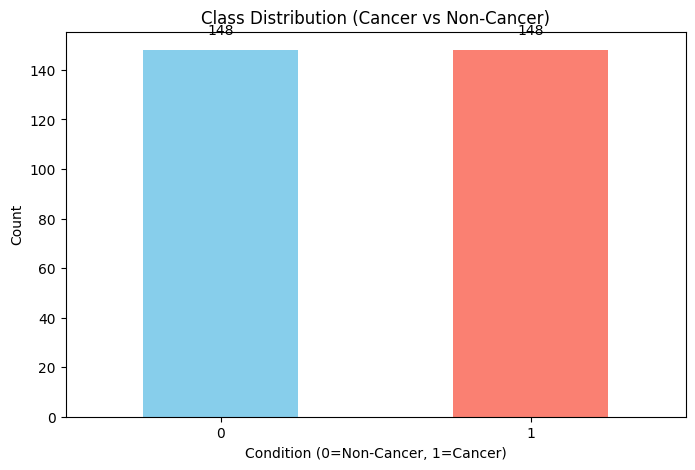


Detailed Class Information:
Total samples: 296
Cancer samples (T.c): 148
Non-cancer samples (N.c): 148
Class ratio (Cancer:Non-Cancer): 1.00:1

Is dataset balanced? Yes


In [7]:
# First, properly encode cancer (1) vs non-cancer (0) labels
# Based on the pattern: 'T.c' indicates tumor (cancer), 'N.c' indicates normal
merged_data['Condition_encoded'] = merged_data['Condition'].apply(
    lambda x: 1 if 'T.c' in x else 0
)

# Now analyze the class distribution
class_distribution = merged_data['Condition_encoded'].value_counts()

print("Class Distribution:")
print(class_distribution)

# Visualize the distribution
plt.figure(figsize=(8, 5))
ax = class_distribution.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Class Distribution (Cancer vs Non-Cancer)')
plt.xlabel('Condition (0=Non-Cancer, 1=Cancer)')
plt.ylabel('Count')
plt.xticks(rotation=0)

# Add count labels on top of each bar
for i in ax.patches:
    ax.text(i.get_x() + i.get_width()/2, i.get_height() + 5, 
            str(i.get_height()), 
            ha='center', va='bottom')

plt.show()

# Detailed analysis
print("\nDetailed Class Information:")
print(f"Total samples: {len(merged_data)}")
print(f"Cancer samples (T.c): {class_distribution.get(1, 0)}")
print(f"Non-cancer samples (N.c): {class_distribution.get(0, 0)}")
if class_distribution.get(0, 0) > 0:
    ratio = class_distribution.get(1, 0)/class_distribution.get(0, 0)
    print(f"Class ratio (Cancer:Non-Cancer): {ratio:.2f}:1")
else:
    print("No non-cancer samples found")

# Check if dataset is balanced
threshold = 0.3  # Consider imbalance if ratio is beyond 30%
if class_distribution.get(0, 0) > 0:
    is_balanced = abs(class_distribution[1]/class_distribution[0] - 1) < threshold
    print(f"\nIs dataset balanced? {'Yes' if is_balanced else 'No'}")
else:
    print("\nWarning: Only cancer samples found - extreme imbalance")

In [8]:
# Get the shape of the dataset
dataset_shape = merged_data.shape

# Display the shape information
print(f"Shape of the dataset: {dataset_shape}")
print(f"Number of samples (rows): {dataset_shape[0]}")
print(f"Number of features (columns): {dataset_shape[1]}")

# Breakdown of feature types
numeric_cols = merged_data.select_dtypes(include=[np.number]).columns
non_numeric_cols = merged_data.select_dtypes(exclude=[np.number]).columns

print(f"\nDetailed breakdown:")
print(f"- Numeric features (gene expression values): {len(numeric_cols)}")
print(f"- Non-numeric features (metadata): {len(non_numeric_cols)}")
print(f"  - Sample IDs: {'Sample' in non_numeric_cols}")
print(f"  - Condition labels: {'Condition' in non_numeric_cols}")
print(f"  - Encoded condition labels: {'Condition_encoded' in merged_data.columns}")

Shape of the dataset: (296, 62979)
Number of samples (rows): 296
Number of features (columns): 62979

Detailed breakdown:
- Numeric features (gene expression values): 62977
- Non-numeric features (metadata): 2
  - Sample IDs: True
  - Condition labels: True
  - Encoded condition labels: True


In [9]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Separate features (X) and target (y)
X = merged_data.drop(['Sample', 'Condition', 'Condition_encoded'], axis=1)  # Gene expression data
y = merged_data['Condition_encoded']  # Binary labels (0=Normal, 1=Cancer)

print("Initial shape:", X.shape)  # Should be (296, 62976)

Initial shape: (296, 62976)


In [10]:
# Keep features with variance > 50th percentile
var_threshold = VarianceThreshold(threshold=np.percentile(X.var(), 50))
X_highvar = var_threshold.fit_transform(X)

print("\nAfter variance thresholding:", X_highvar.shape)  # ~31,488 features remaining

# Get selected gene names
selected_genes_mask = var_threshold.get_support()
selected_genes = X.columns[selected_genes_mask]


After variance thresholding: (296, 31342)


In [11]:
# Select top 1,000 most cancer-discriminative genes
k_best = SelectKBest(f_classif, k=1000)
X_kbest = k_best.fit_transform(X_highvar, y)

print("After K-best selection:", X_kbest.shape)  # (296, 1000)

# Get indices of selected genes
selected_indices = k_best.get_support(indices=True)
important_genes = selected_genes[selected_indices]

After K-best selection: (296, 1000)



Final reduced shape: (296, 53)


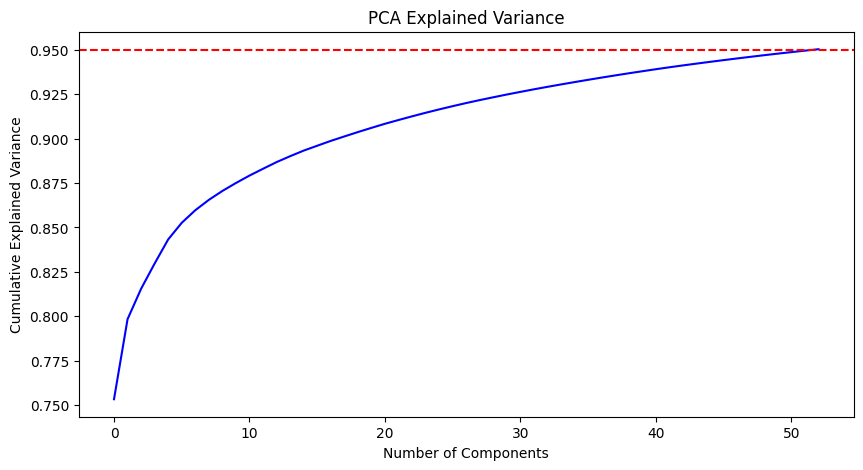

In [12]:
# Scale data before PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_kbest)

# Apply PCA (keep 95% variance)
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

print("\nFinal reduced shape:", X_pca.shape)  # Typically ~50-100 components

# Plot explained variance
plt.figure(figsize=(10,5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), 'b-')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.axhline(y=0.95, color='r', linestyle='--')
plt.title('PCA Explained Variance')
plt.show()

In [13]:
# Create final DataFrame
reduced_df = pd.DataFrame(X_pca, index=merged_data['Sample'])
reduced_df['Condition'] = y.values

# Save gene information for interpretation
gene_info = pd.DataFrame({
    'Gene': important_genes,
    'F_score': k_best.scores_[selected_indices],
    'P_value': k_best.pvalues_[selected_indices]
}).sort_values('F_score', ascending=False)

gene_info.to_csv('selected_genes_info.csv', index=False)
reduced_df.to_csv('reduced_breast_cancer_data.csv')

Class labels after feature reduction:
Total samples: 296
Cancer samples (1): 148
Non-cancer samples (0): 148


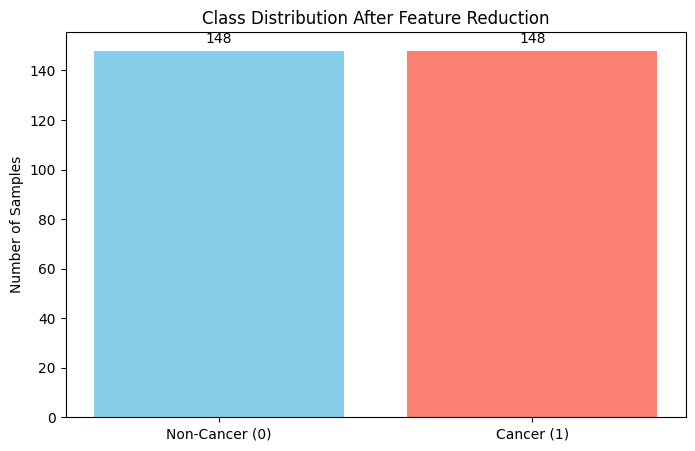


Verification from saved file:
Condition
0    148
1    148
Name: count, dtype: int64


In [14]:
# After running the feature reduction pipeline (X_pca contains reduced features)

# 1. Verify class labels are preserved
print("Class labels after feature reduction:")
print("Total samples:", len(y))
print("Cancer samples (1):", sum(y == 1))
print("Non-cancer samples (0):", sum(y == 0))

# 2. Visualize the distribution
plt.figure(figsize=(8, 5))
plt.bar(['Non-Cancer (0)', 'Cancer (1)'], [sum(y == 0), sum(y == 1)], 
        color=['skyblue', 'salmon'])
plt.title('Class Distribution After Feature Reduction')
plt.ylabel('Number of Samples')

# Add count labels
for i, count in enumerate([sum(y == 0), sum(y == 1)]):
    plt.text(i, count + 2, str(count), ha='center', va='bottom')

plt.show()

# 3. Verify in the saved reduced dataset
reduced_df = pd.read_csv('reduced_breast_cancer_data.csv')
print("\nVerification from saved file:")
print(reduced_df['Condition'].value_counts())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.5/156.5 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.5/52.5 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.3/69.3 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.4/193.4 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 47.9 MB/s eta 0:00:0000:01
Original dataset size: 296
Generating 352 synthetic cancer samples
Generating 352 synthetic normal samples

Training CTGAN on cancer samples...


Gen. (-1.62) | Discrim. (0.89): 100%|██████████| 200/200 [00:23<00:00,  8.48it/s] 



Training CTGAN on normal samples...


Gen. (-0.20) | Discrim. (-1.12): 100%|██████████| 200/200 [00:22<00:00,  8.72it/s]



Augmented dataset statistics:
Original samples: 296
Synthetic cancer samples: 352
Synthetic normal samples: 352
Total samples: 1000
Cancer samples: 500
Normal samples: 500


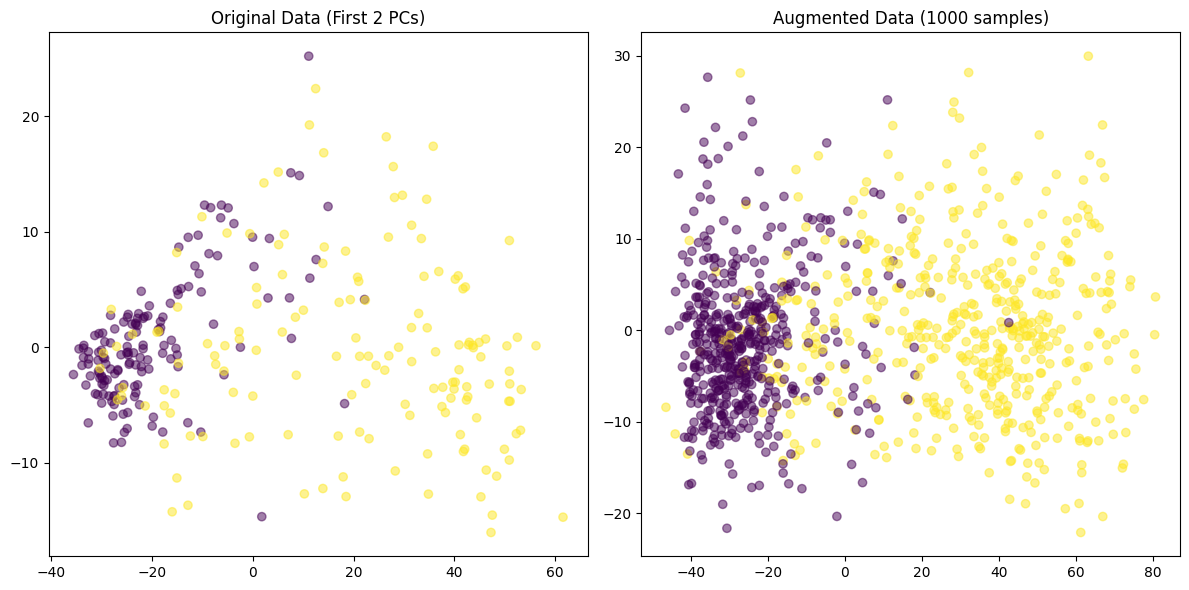

In [15]:
# import torch
# import torch.nn as nn
# from torch.utils.data import DataLoader, TensorDataset
# import numpy as np
# import matplotlib.pyplot as plt

# # Convert data to PyTorch tensors
# X_tensor = torch.FloatTensor(X_pca)  # Reduced features from PCA
# y_tensor = torch.FloatTensor(y.values).reshape(-1, 1)

# # Create separate datasets for each class
# cancer_data = X_tensor[y_tensor.flatten() == 1]
# normal_data = X_tensor[y_tensor.flatten() == 0]

# # Calculate how many samples to generate for each class to reach ~1000 total
# original_count = len(X_pca)
# target_count = 1000
# additional_needed = target_count - original_count

# # Distribute additional samples proportionally to original class distribution
# cancer_ratio = len(cancer_data) / original_count
# normal_ratio = len(normal_data) / original_count

# synth_cancer_needed = int(additional_needed * cancer_ratio)
# synth_normal_needed = int(additional_needed * normal_ratio)

# print(f"Original dataset size: {original_count}")
# print(f"Generating {synth_cancer_needed} synthetic cancer samples")
# print(f"Generating {synth_normal_needed} synthetic normal samples")

# class Generator(nn.Module):
#     def __init__(self, latent_dim, output_dim):
#         super().__init__()
#         self.model = nn.Sequential(
#             nn.Linear(latent_dim, 128),
#             nn.LeakyReLU(0.2),
#             nn.Linear(128, 256),
#             nn.LeakyReLU(0.2),
#             nn.Linear(256, output_dim),
#             nn.Tanh()
#         )
    
#     def forward(self, z):
#         return self.model(z)

# class Discriminator(nn.Module):
#     def __init__(self, input_dim):
#         super().__init__()
#         self.model = nn.Sequential(
#             nn.Linear(input_dim, 256),
#             nn.LeakyReLU(0.2),
#             nn.Linear(256, 128),
#             nn.LeakyReLU(0.2),
#             nn.Linear(128, 1),
#             nn.Sigmoid()
#         )
    
#     def forward(self, x):
#         return self.model(x)

# def train_gan(data, n_samples, epochs=1000, batch_size=32):
#     """Train GAN to generate synthetic samples for one class"""
#     # Initialize
#     latent_dim = 32
#     input_dim = data.shape[1]
#     device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
#     # Models
#     generator = Generator(latent_dim, input_dim).to(device)
#     discriminator = Discriminator(input_dim).to(device)
    
#     # Optimizers
#     g_optimizer = torch.optim.Adam(generator.parameters(), lr=0.0002)
#     d_optimizer = torch.optim.Adam(discriminator.parameters(), lr=0.0002)
    
#     # Loss
#     criterion = nn.BCELoss()
    
#     # Data loader
#     dataset = TensorDataset(data)
#     dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
#     # Training loop
#     for epoch in range(epochs):
#         for real_data, in dataloader:
#             real_data = real_data.to(device)
#             batch_size = real_data.size(0)
            
#             # Train Discriminator
#             d_optimizer.zero_grad()
            
#             # Real data
#             real_labels = torch.ones(batch_size, 1).to(device)
#             d_real_loss = criterion(discriminator(real_data), real_labels)
            
#             # Fake data
#             z = torch.randn(batch_size, latent_dim).to(device)
#             fake_data = generator(z)
#             fake_labels = torch.zeros(batch_size, 1).to(device)
#             d_fake_loss = criterion(discriminator(fake_data.detach()), fake_labels)
            
#             d_loss = d_real_loss + d_fake_loss
#             d_loss.backward()
#             d_optimizer.step()
            
#             # Train Generator
#             g_optimizer.zero_grad()
#             z = torch.randn(batch_size, latent_dim).to(device)
#             fake_data = generator(z)
#             g_loss = criterion(discriminator(fake_data), real_labels)
#             g_loss.backward()
#             g_optimizer.step()
    
#     # Generate synthetic samples
#     z = torch.randn(n_samples, latent_dim).to(device)
#     synthetic_samples = generator(z).detach().cpu().numpy()
#     return synthetic_samples

# # Generate synthetic samples for both classes
# print("\nGenerating synthetic cancer samples...")
# synthetic_cancer = train_gan(cancer_data, n_samples=synth_cancer_needed)

# print("Generating synthetic normal samples...")
# synthetic_normal = train_gan(normal_data, n_samples=synth_normal_needed)

# # Combine with original data
# X_augmented = np.vstack([X_pca, synthetic_cancer, synthetic_normal])
# y_augmented = np.hstack([y, np.ones(len(synthetic_cancer)), np.zeros(len(synthetic_normal))])

# # Verify new distribution
# print("\nAugmented dataset statistics:")
# print(f"Original samples: {original_count}")
# print(f"Synthetic cancer samples: {len(synthetic_cancer)}")
# print(f"Synthetic normal samples: {len(synthetic_normal)}")
# print(f"Total samples: {len(y_augmented)}")
# print(f"Cancer samples: {sum(y_augmented == 1)}")
# print(f"Normal samples: {sum(y_augmented == 0)}")

# # Visualize
# plt.figure(figsize=(12, 6))
# plt.subplot(1, 2, 1)
# plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, alpha=0.5)
# plt.title("Original Data (First 2 PCs)")

# plt.subplot(1, 2, 2)
# plt.scatter(X_augmented[:, 0], X_augmented[:, 1], c=y_augmented, alpha=0.5)
# plt.title(f"Augmented Data ({len(y_augmented)} samples)")
# plt.tight_layout()
# plt.show()
!pip install ctgan sdv --quiet
from ctgan import CTGAN
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Convert PCA data to DataFrame with proper column names
pca_columns = [f'PC_{i}' for i in range(X_pca.shape[1])]
pca_df = pd.DataFrame(X_pca, columns=pca_columns)
pca_df['Condition'] = y.values.astype(int)  # Ensure condition is integer

# Split data by class
cancer_data = pca_df[pca_df['Condition'] == 1].copy()
normal_data = pca_df[pca_df['Condition'] == 0].copy()

# Remove the condition column before fitting CTGAN
cancer_features = cancer_data.drop('Condition', axis=1)
normal_features = normal_data.drop('Condition', axis=1)

# Calculate samples needed
original_count = len(pca_df)
target_count = 1000
additional_needed = target_count - original_count
cancer_ratio = len(cancer_data) / original_count
normal_ratio = len(normal_data) / original_count
synth_cancer_needed = int(additional_needed * cancer_ratio)
synth_normal_needed = int(additional_needed * normal_ratio)

print(f"Original dataset size: {original_count}")
print(f"Generating {synth_cancer_needed} synthetic cancer samples")
print(f"Generating {synth_normal_needed} synthetic normal samples")

# CTGAN configuration with more stable parameters
ctgan_params = {
    'epochs': 200,
    'batch_size': 50,
    'generator_dim': (128, 128),
    'discriminator_dim': (128, 128),
    'verbose': True,
    'pac': 10  # Helps with stability
}

# Train CTGAN on cancer samples
print("\nTraining CTGAN on cancer samples...")
ctgan_cancer = CTGAN(**ctgan_params)
ctgan_cancer.fit(cancer_features, [])  # Empty list for no discrete columns
synthetic_cancer = ctgan_cancer.sample(synth_cancer_needed)
synthetic_cancer['Condition'] = 1  # Add label back

# Train CTGAN on normal samples
print("\nTraining CTGAN on normal samples...")
ctgan_normal = CTGAN(**ctgan_params)
ctgan_normal.fit(normal_features, [])  # Empty list for no discrete columns
synthetic_normal = ctgan_normal.sample(synth_normal_needed)
synthetic_normal['Condition'] = 0  # Add label back

# Combine datasets
X_augmented = np.vstack([
    X_pca,
    synthetic_cancer.drop('Condition', axis=1).values,
    synthetic_normal.drop('Condition', axis=1).values
])
y_augmented = np.hstack([
    y,
    synthetic_cancer['Condition'].values,
    synthetic_normal['Condition'].values
])

# Verify new distribution
print("\nAugmented dataset statistics:")
print(f"Original samples: {original_count}")
print(f"Synthetic cancer samples: {len(synthetic_cancer)}")
print(f"Synthetic normal samples: {len(synthetic_normal)}")
print(f"Total samples: {len(y_augmented)}")
print(f"Cancer samples: {sum(y_augmented == 1)}")
print(f"Normal samples: {sum(y_augmented == 0)}")

# Visualize
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, alpha=0.5)
plt.title("Original Data (First 2 PCs)")

plt.subplot(1, 2, 2)
plt.scatter(X_augmented[:, 0], X_augmented[:, 1], c=y_augmented, alpha=0.5)
plt.title(f"Augmented Data ({len(y_augmented)} samples)")
plt.tight_layout()
plt.show()

Fitting 5 folds for each of 12 candidates, totalling 60 fits
✅ Best Parameters: {'C': 5, 'gamma': 'scale', 'kernel': 'rbf'}

✅ Classification Report:
              precision    recall  f1-score   support

  Non-Cancer       0.96      0.96      0.96       100
      Cancer       0.96      0.96      0.96       100

    accuracy                           0.96       200
   macro avg       0.96      0.96      0.96       200
weighted avg       0.96      0.96      0.96       200



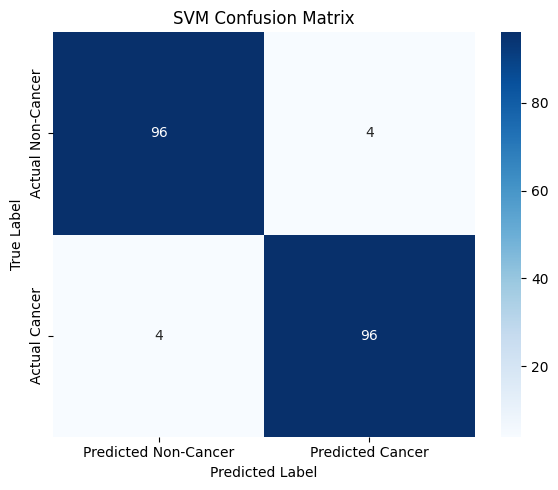

✅ Final SVM Accuracy: 96.00%


In [16]:
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Step 1: Standardize Features (Essential for SVM)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_augmented)

# Step 2: Stratified Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_augmented,
    test_size=0.2,
    stratify=y_augmented,
    random_state=42
)

# Step 3: Hyperparameter Tuning using Stratified K-Fold
param_grid = {
    'C': [0.5, 1, 5, 10],
    'gamma': ['scale', 0.01, 0.001],
    'kernel': ['rbf']
}

grid_svm = GridSearchCV(
    estimator=SVC(probability=True, class_weight='balanced', random_state=42),
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_svm.fit(X_train, y_train)

# Step 4: Evaluate Best Model
svm_best = grid_svm.best_estimator_
y_pred = svm_best.predict(X_test)

# Print best params
print(f"✅ Best Parameters: {grid_svm.best_params_}")

# Classification Report
print("\n✅ Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Non-Cancer", "Cancer"]))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Predicted Non-Cancer", "Predicted Cancer"],
            yticklabels=["Actual Non-Cancer", "Actual Cancer"])
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

# Final Accuracy
final_accuracy = np.mean(y_pred == y_test) * 100
print(f"✅ Final SVM Accuracy: {final_accuracy:.2f}%")


Fitting 5 folds for each of 36 candidates, totalling 180 fits

✅ Best Hyperparameters:
{'activation': 'relu', 'alpha': 0.001, 'batch_size': 32, 'early_stopping': True, 'hidden_layer_sizes': (128, 64), 'learning_rate': 'adaptive', 'max_iter': 1000, 'n_iter_no_change': 20, 'validation_fraction': 0.2}

🎯 Accuracy Summary:
Training Accuracy   : 0.9900
Validation Accuracy : 0.9875
Test Accuracy       : 0.9800
Epochs Trained      : 33

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       100
           1       0.99      0.97      0.98       100

    accuracy                           0.98       200
   macro avg       0.98      0.98      0.98       200
weighted avg       0.98      0.98      0.98       200



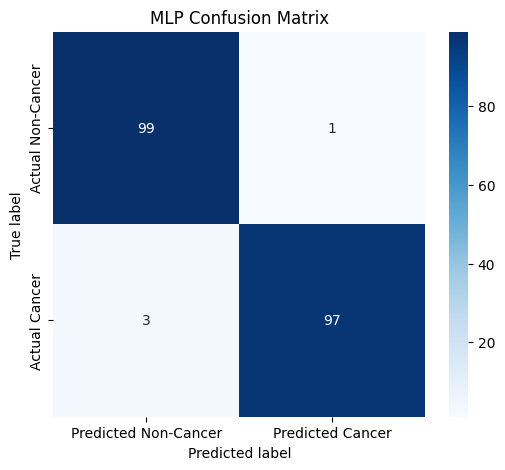

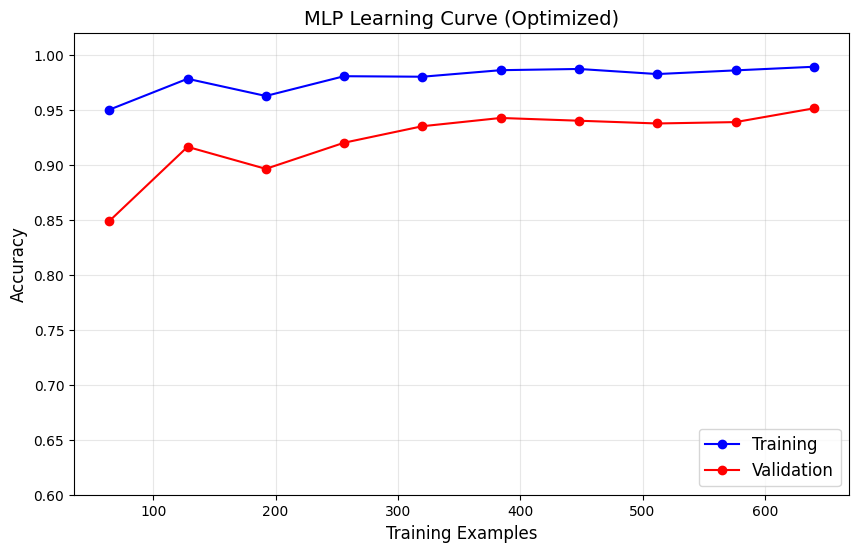

In [17]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV, train_test_split, learning_curve
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Standardize the features
scaler = StandardScaler()
X_aug_scaled = scaler.fit_transform(X_augmented)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_aug_scaled, y_augmented, test_size=0.2, stratify=y_augmented, random_state=42
)

# Further split for validation check
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
)

# Grid Search for Hyperparameter Tuning
param_grid = {
    'hidden_layer_sizes': [(128, 64), (100, 50), (64, 32)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate': ['adaptive'],
    'batch_size': [32, 64],
    'max_iter': [1000],
    'early_stopping': [True],
    'validation_fraction': [0.2],
    'n_iter_no_change': [20]
}

grid_search = GridSearchCV(
    MLPClassifier(random_state=42),
    param_grid,
    scoring='accuracy',
    cv=5,
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train_sub, y_train_sub)

# Best MLP model
best_mlp = grid_search.best_estimator_
print("\n✅ Best Hyperparameters:")
print(grid_search.best_params_)

# Final Training on full training set
best_mlp.fit(X_train, y_train)

# Evaluate on all sets
train_acc = best_mlp.score(X_train, y_train)
val_acc = best_mlp.score(X_val, y_val)
test_acc = best_mlp.score(X_test, y_test)

print("\n🎯 Accuracy Summary:")
print(f"Training Accuracy   : {train_acc:.4f}")
print(f"Validation Accuracy : {val_acc:.4f}")
print(f"Test Accuracy       : {test_acc:.4f}")
print(f"Epochs Trained      : {best_mlp.n_iter_}")

# Classification Report & Confusion Matrix
y_pred = best_mlp.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Non-Cancer', 'Predicted Cancer'],
            yticklabels=['Actual Non-Cancer', 'Actual Cancer'])
plt.title('MLP Confusion Matrix')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

# Learning Curve
train_sizes, train_scores, val_scores = learning_curve(
    best_mlp, X_train, y_train, cv=5,
    scoring='accuracy', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10),
    shuffle=True,
    random_state=42
)

plt.figure(figsize=(10, 6))
plt.ylim(0.6, 1.02)
plt.plot(train_sizes, np.mean(train_scores, axis=1), 'o-', color="blue", label="Training")
plt.plot(train_sizes, np.mean(val_scores, axis=1), 'o-', color="red", label="Validation")
plt.title("MLP Learning Curve (Optimized)", fontsize=14)
plt.xlabel("Training Examples", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(loc="lower right", fontsize=12)
plt.show()


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 59ms/step - accuracy: 0.5858 - loss: 0.8808 - val_accuracy: 0.5938 - val_loss: 0.8107 - learning_rate: 5.0000e-04
Epoch 2/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7454 - loss: 0.6838 - val_accuracy: 0.8062 - val_loss: 0.8070 - learning_rate: 5.0000e-04
Epoch 3/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8157 - loss: 0.5972 - val_accuracy: 0.5625 - val_loss: 0.8355 - learning_rate: 5.0000e-04
Epoch 4/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8473 - loss: 0.5434 - val_accuracy: 0.4812 - val_loss: 0.8522 - learning_rate: 5.0000e-04
Epoch 5/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8402 - loss: 0.5402 - val_accuracy: 0.4812 - val_loss: 0.8529 - learning_rate: 5.0000e-04
Epoch 6/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8530 - loss: 0.5170 - val_accuracy: 0.4812 - val_loss: 0.8606 - learning_rate: 5.0000e-04
Epoch 7/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8499

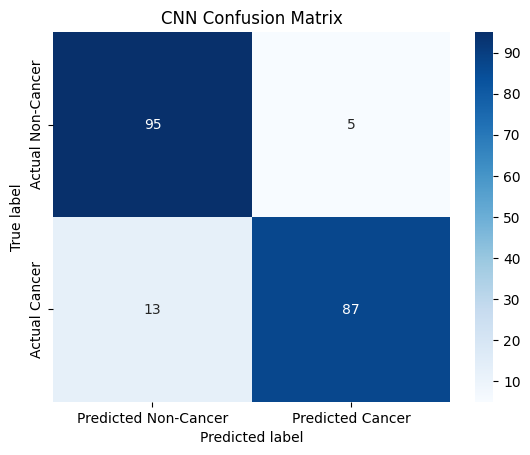

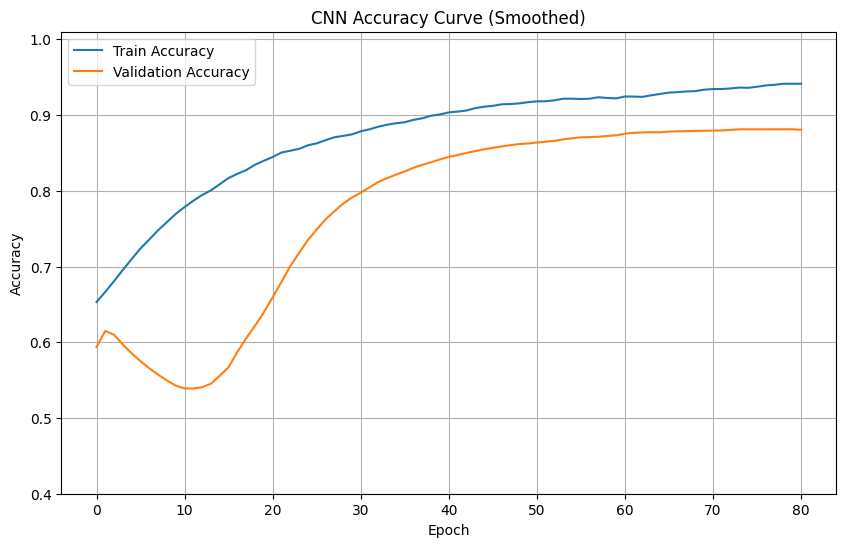

Test Accuracy: 0.9100
ROC-AUC Score: 0.9769


In [18]:
import tensorflow as tf
from tensorflow.keras import layers, regularizers, callbacks
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_augmented)
y = y_augmented

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42)

# Expand dims for CNN input
X_train = np.expand_dims(X_train, axis=2)
X_test = np.expand_dims(X_test, axis=2)

# Define CNN model with hyperparameter tuning options
def create_cnn_model(input_shape, dropout_rate=0.4, l2_reg=0.001):
    model = tf.keras.Sequential([
        layers.Conv1D(64, 3, activation='relu', padding='same', kernel_regularizer=regularizers.l2(l2_reg), input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling1D(2),

        layers.Conv1D(128, 3, activation='relu', padding='same', kernel_regularizer=regularizers.l2(l2_reg)),
        layers.BatchNormalization(),
        layers.MaxPooling1D(2),

        layers.GlobalAveragePooling1D(),
        layers.Dropout(dropout_rate),
        layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(l2_reg)),
        layers.Dense(2, activation='softmax')
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Callbacks
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
lr_schedule = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)

# Create and train model
model = create_cnn_model((X_train.shape[1], 1))
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    callbacks=[early_stop, lr_schedule],
    verbose=1
)

# Predict
y_pred = np.argmax(model.predict(X_test), axis=1)
y_proba = model.predict(X_test)[:, 1]

# Evaluation
print("\n✅ Classification Report (CNN):")
print(classification_report(y_test, y_pred, target_names=["Non-Cancer", "Cancer"]))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted Non-Cancer", "Predicted Cancer"],
            yticklabels=["Actual Non-Cancer", "Actual Cancer"])
plt.title("CNN Confusion Matrix")
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.show()

# Smooth training curves
def smooth_curve(points, factor=0.9):
    smoothed = []
    last = points[0]
    for point in points:
        smoothed_val = last * factor + (1 - factor) * point
        smoothed.append(smoothed_val)
        last = smoothed_val
    return smoothed

# Accuracy plot
plt.figure(figsize=(10, 6))
plt.plot(smooth_curve(history.history['accuracy']), label='Train Accuracy')
plt.plot(smooth_curve(history.history['val_accuracy']), label='Validation Accuracy')
plt.title('CNN Accuracy Curve (Smoothed)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)
plt.ylim(0.4, 1.01)
plt.legend()
plt.show()

# Final scores
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")


Epoch 1/200


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0.5656 - loss: 1.1014 - val_accuracy: 0.6625 - val_loss: 0.7919 - learning_rate: 2.0000e-04
Epoch 2/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6671 - loss: 0.8541 - val_accuracy: 0.7875 - val_loss: 0.7268 - learning_rate: 2.0000e-04
Epoch 3/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7420 - loss: 0.8095 - val_accuracy: 0.8250 - val_loss: 0.6799 - learning_rate: 2.0000e-04
Epoch 4/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7255 - loss: 0.7418 - val_accuracy: 0.8313 - val_loss: 0.6447 - learning_rate: 2.0000e-04
Epoch 5/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7845 - loss: 0.6785 - val_accuracy: 0.8375 - val_loss: 0.6165 - learning_rate: 2.0000e-04
Epoch 6/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7888 - loss: 0.6459 - val_accuracy: 0.8500 - val_loss: 0.5925 - learning_rate: 2.0000e-04
Epoch 7/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7758 - loss: 0.6

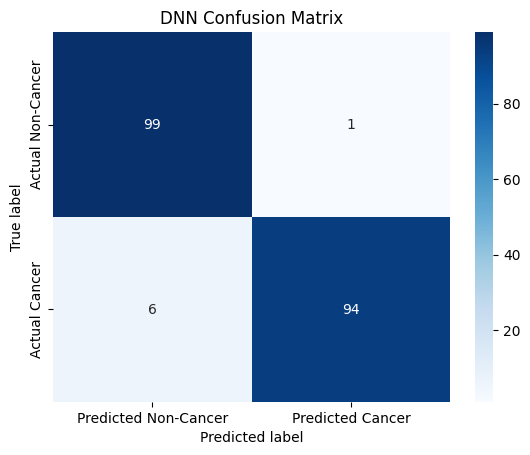

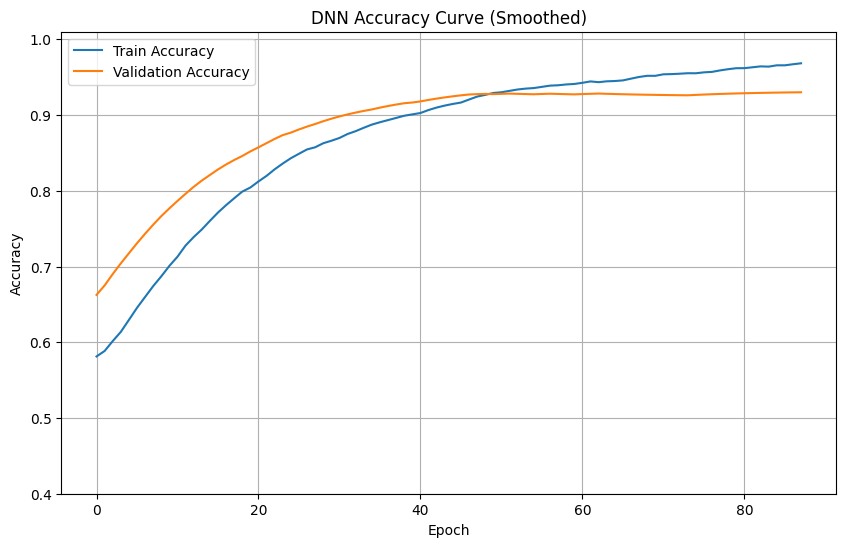


🎯 Final Accuracy Summary:
Training Accuracy   : 0.9797
Validation Accuracy : 0.9312
Test Accuracy       : 0.9650
ROC-AUC Score       : 0.9979


In [19]:
import tensorflow as tf
from tensorflow.keras import layers, regularizers, callbacks
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_augmented)
y = y_augmented

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42)

# Define DNN model with updated hyperparameters for reduced overfitting
def create_dnn_model(input_dim, dropout_rate=0.3, l2_reg=0.001):
    model = tf.keras.Sequential([
        layers.Dense(128, activation='relu', input_shape=(input_dim,),
                      kernel_regularizer=regularizers.l2(l2_reg)),
        layers.BatchNormalization(),
        layers.Dropout(dropout_rate),

        layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(l2_reg)),
        layers.BatchNormalization(),
        layers.Dropout(dropout_rate),

        layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(l2_reg)),
        layers.BatchNormalization(),
        layers.Dropout(dropout_rate),

        layers.Dense(2, activation='softmax')
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0002),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Callbacks
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True)
lr_schedule = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-5)

# Create and train model
model = create_dnn_model(X_train.shape[1])
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    callbacks=[early_stop, lr_schedule],
    verbose=1
)

# Predict
y_pred = np.argmax(model.predict(X_test), axis=1)
y_proba = model.predict(X_test)[:, 1]

# Evaluation
print("\n✅ Classification Report (DNN):")
print(classification_report(y_test, y_pred, target_names=["Non-Cancer", "Cancer"]))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted Non-Cancer", "Predicted Cancer"],
            yticklabels=["Actual Non-Cancer", "Actual Cancer"])
plt.title("DNN Confusion Matrix")
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.show()

# Smooth training curves
def smooth_curve(points, factor=0.9):
    smoothed = []
    last = points[0]
    for point in points:
        smoothed_val = last * factor + (1 - factor) * point
        smoothed.append(smoothed_val)
        last = smoothed_val
    return smoothed

# Accuracy plot
plt.figure(figsize=(10, 6))
plt.plot(smooth_curve(history.history['accuracy']), label='Train Accuracy')
plt.plot(smooth_curve(history.history['val_accuracy']), label='Validation Accuracy')
plt.title('DNN Accuracy Curve (Smoothed)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)
plt.ylim(0.4, 1.01)
plt.legend()
plt.show()

# Final scores
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
final_test_acc = accuracy_score(y_test, y_pred)

print("\n🎯 Final Accuracy Summary:")
print(f"Training Accuracy   : {final_train_acc:.4f}")
print(f"Validation Accuracy : {final_val_acc:.4f}")
print(f"Test Accuracy       : {final_test_acc:.4f}")
print(f"ROC-AUC Score       : {roc_auc_score(y_test, y_proba):.4f}")
